# 7 · Does the gap bite on *real* data? — the LaLonde validation

Every earlier notebook is synthetic: I made the confounding true, so of course causal beats predictive.
The fair test is real data **with an experimental ground truth**, so the causal estimate can be
*checked*, not asserted. The canonical such dataset is **LaLonde's National Supported Work (NSW)** job-
training experiment (Dehejia–Wahba subset):

- a **randomised trial** gives the true effect of the program on 1978 earnings (the benchmark);
- a **non-experimental** version swaps the randomised controls for a survey comparison group (CPS),
  reproducing the confounding a real observational analyst faces.

This validates the **identification core of CHC** — the part that decides *what effect feeds the
controller*. (The control loop itself is still the synthetic demo; here we stress-test the causal claim
it rests on.) Provenance: R. Dehejia & S. Wahba (2002), data via NBER; nothing is committed to the repo.

In [1]:
import pathlib
import urllib.request

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

jax.config.update("jax_enable_x64", True)
%matplotlib inline

from chc.causal import estimate_control_effect, estimate_effect_dml

DATA = pathlib.Path("data")
DATA.mkdir(exist_ok=True)


def load(name: str) -> pd.DataFrame:
    """Load a Dehejia-Wahba .dta, downloading to a local (git-ignored) cache on first use."""
    path = DATA / f"{name}.dta"
    if not path.exists():
        urllib.request.urlretrieve(f"http://users.nber.org/~rdehejia/data/{name}.dta", path)
    return pd.read_stata(path)


COV = ["age", "education", "black", "hispanic", "married", "nodegree", "re74", "re75"]
experimental = load("nsw_dw")  # randomised: NSW treated + randomised controls
cps = load("cps_controls")  # a survey comparison group (the confounding)
for df in (experimental, cps):  # earnings in $1000s keeps the numbers (and DML polynomials) sane
    df[["re74", "re75", "re78"]] /= 1000.0


def to_chc(df: pd.DataFrame) -> dict:
    """Pack a frame into the column dict chc.causal expects (u = treatment, x_next = outcome)."""
    d = {"u": jnp.asarray(df.treat.values, float), "x_next": jnp.asarray(df.re78.values, float)}
    d["x"] = jnp.asarray(df.age.values, float)  # the always-included base regressor
    for c in COV:
        d[c] = jnp.asarray(df[c].values, float)
    return d

## The experimental benchmark (ground truth)

Because treatment was randomised, a plain difference in mean 1978 earnings is already unbiased.

In [2]:
truth = float(
    experimental.loc[experimental.treat == 1, "re78"].mean()
    - experimental.loc[experimental.treat == 0, "re78"].mean()
)
print(f"experimental ATT (randomised, difference in means) = {truth * 1000:+,.0f} $/yr")
print(f"  {int((experimental.treat == 1).sum())} treated vs "
      f"{int((experimental.treat == 0).sum())} randomised controls")

experimental ATT (randomised, difference in means) = +1,794 $/yr
  185 treated vs 260 randomised controls


## The observational trap: a comparison group that isn't comparable

Now replace the randomised controls with the CPS survey group — what an analyst *without* an experiment
would use. The groups differ sharply on every covariate (the CPS men are older, more educated, married,
and earned far more before the program), so any naive contrast confounds the program with these gaps.

In [3]:
obs = pd.concat([experimental[experimental.treat == 1], cps], ignore_index=True)
balance = (
    obs.groupby("treat")[["age", "education", "married", "re74", "re75"]]
    .mean()
    .rename(index={0: "CPS comparison", 1: "NSW treated"})
)
balance.round(2)

,age,education,married,re74,re75
treat,,,,,
CPS comparison,33.23,12.03,0.71,14.02,13.65
NSW treated,25.82,10.35,0.19,2.10,1.53


## Naive vs causal — checked against the truth

- **naive** (difference in means): what a predictive/associational read of the logs says;
- **OLS-adjusted** (`estimate_control_effect`): linear backdoor adjustment for the covariates;
- **Double ML** (`estimate_effect_dml`): cross-fitted, Neyman-orthogonal residualisation with flexible
  (polynomial) nuisances — the estimator meant to survive this kind of imbalance.

In [4]:
naive = float(obs.loc[obs.treat == 1, "re78"].mean() - obs.loc[obs.treat == 0, "re78"].mean())
ols_adj = float(estimate_control_effect(to_chc(obs), adjust_for=tuple(COV[1:])))
dml = float(estimate_effect_dml(to_chc(obs), covariates=tuple(COV), degree=2, folds=5, ridge=1.0))

table = pd.DataFrame(
    {"estimate ($/yr)": [truth * 1000, naive * 1000, ols_adj * 1000, dml * 1000]},
    index=[
        "experimental TRUTH",
        "naive (predictive)",
        "OLS-adjusted (CHC)",
        "Double ML (CHC)",
    ],
).round(0)
table["error vs truth"] = ((table["estimate ($/yr)"] - truth * 1000)).round(0)
table

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


,estimate ($/yr),error vs truth
experimental TRUTH,1794.0,-0.0
naive (predictive),-8498.0,-10292.0
OLS-adjusted (CHC),699.0,-1095.0
Double ML (CHC),1560.0,-234.0


The naive observational estimate is **the wrong sign** — it says the program *destroyed* about
\$8,500/yr of earnings. A decision driven by that predictive read ("kill the program") would be exactly
backwards. CHC's backdoor adjustment restores the correct sign, and **Double ML lands within a few
hundred dollars of the randomised truth** on the same confounded data.

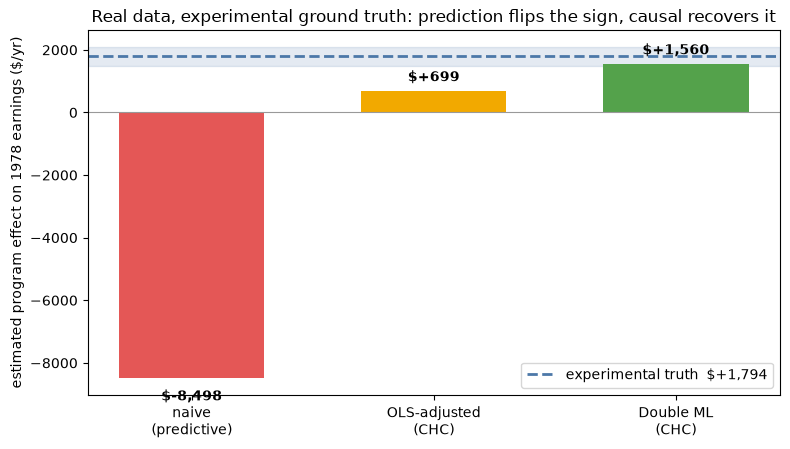

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.6))
methods = ["naive\n(predictive)", "OLS-adjusted\n(CHC)", "Double ML\n(CHC)"]
vals = [naive * 1000, ols_adj * 1000, dml * 1000]
colors = ["#E45756", "#F2A900", "#54A24B"]
ax.axhspan(truth * 1000 - 300, truth * 1000 + 300, color="#4C78A8", alpha=0.15)
ax.axhline(truth * 1000, color="#4C78A8", lw=2, ls="--", label=f"experimental truth  ${truth * 1000:+,.0f}")
ax.axhline(0, color="0.6", lw=0.8)
bars = ax.bar(methods, vals, color=colors, width=0.6)
for b, v in zip(bars, vals, strict=True):
    ax.text(b.get_x() + b.get_width() / 2, v + (300 if v > 0 else -700),
            f"${v:+,.0f}", ha="center", fontweight="bold")
ax.set_ylabel("estimated program effect on 1978 earnings ($/yr)")
ax.set_title("Real data, experimental ground truth: prediction flips the sign, causal recovers it")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Takeaway — the honest answer to "is this real?"

**Yes, the gap bites on real data.** On the LaLonde NSW data the predictive/associational estimate is
not merely biased — it has the **wrong sign**, and a decision made from it would be the opposite of
correct. CHC's causal estimators (adjustment, and especially Double ML) recover the randomised
experimental truth from the confounded observational data.

**Scope, stated honestly:** this validates the *identification* half of CHC — the effect that feeds the
controller — on real data with a checkable ground truth. It does **not** by itself validate the control
loop on real dynamics (that remains the synthetic demo), and the DML number depends on the nuisance
learner (here degree-2 polynomials; richer learners land in the same \$1.0–1.8k range reported in the
literature). What it does settle: the load-bearing premise of the whole library — *use the intervention,
not the prediction, to make the decision* — is real, and expensive to ignore.